In [1]:
import pandas as pd
import time
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, mean_squared_error, r2_score, mean_absolute_error

# load dataset
games = pd.read_csv(r"C:\AnPhi\inst414\nba_dataset_inst414\Cleaned_Games.csv")
games.head()

,gameId,gameDate,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,attendance,arenaId,gameLabel,gameSubLabel,seriesGameNumber
0,42400407,6/22/2025 20:00,Oklahoma City,Thunder,1610612760,Indiana,Pacers,1610612754,103,91,1610612760,Playoffs,18203,1000052,NBA Finals,Game 7,7.0
1,42400406,6/19/2025 20:30,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,108,91,1610612754,Playoffs,17274,1000063,NBA Finals,Game 6,6.0
2,42400405,6/16/2025 20:30,Oklahoma City,Thunder,1610612760,Indiana,Pacers,1610612754,120,109,1610612760,Playoffs,18203,1000052,NBA Finals,Game 5,5.0
3,42400404,6/13/2025 20:30,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,104,111,1610612760,Playoffs,17274,1000063,NBA Finals,Game 4,4.0
4,42400403,6/11/2025 20:30,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,116,107,1610612754,Playoffs,17274,1000063,NBA Finals,Game 3,3.0


In [2]:
games['gameDate'] = pd.to_datetime(games['gameDate'], format = '%m/%d/%Y %H:%M', errors='coerce')

# define seasons
def assign_seasons(date):
    year = date.year
    if date.month >= 10:
        return f"{year}-{year+1}"
    else:
        return f"{year-1}-{year}"

games['season'] = games['gameDate'].apply(assign_seasons)
games = games.sort_values(['season', 'gameDate']).reset_index(drop=True)

# home and away win pct per season calculation
games['homeSeasonWinPct'] = 0.0
games['awaySeasonWinPct'] = 0.0

# separate seasons
for season in games['season'].unique():
    season_games = games[games['season'] == season].copy()

    # tracking wins and games for each team
    team_wins = {}
    team_games = {}

    # season lists
    season_home_win_pct_list = []
    season_away_win_pct_list = []

    for idx, row in season_games.iterrows():
        home_team = row['hometeamId']
        away_team = row['awayteamId']

        # win pct
        home_pct = team_wins.get(home_team, 0) / max(team_games.get(home_team, 1), 1)
        away_pct = team_wins.get(away_team, 0) / max(team_games.get(away_team, 1), 1)

        season_home_win_pct_list.append(home_pct)
        season_away_win_pct_list.append(away_pct)

        # games played update
        team_games[home_team] = team_games.get(home_team, 0) + 1
        team_games[away_team] = team_games.get(away_team, 0) + 1

        # wins update
        if row['winner'] == home_team:
            team_wins[home_team] = team_wins.get(home_team, 0) + 1
        else:
            team_wins[away_team] = team_wins.get(away_team, 0) + 1

    # add columns to games by season
    season_indices = games[games['season'] == season].index
    games.loc[season_indices, 'homeSeasonWinPct'] = season_home_win_pct_list
    games.loc[season_indices, 'awaySeasonWinPct'] = season_away_win_pct_list

**Logistic Regression Model**

In [3]:
### MODEL A (No interaction)
# create predictor variables
games['playoffs'] = games['gameType'].apply(lambda x: 1 if x == 'Playoffs' else 0)
games['homeWin'] = games.apply(lambda row: 1 if row['winner'] == row['hometeamId'] else 0, axis = 1)

# defining predictor and target variables
X = games[['homeSeasonWinPct', 'awaySeasonWinPct', 'playoffs']]
y = games['homeWin']

# spliting dataset (70% training, 15% validation, 15% testing)
# 70% training and 30% temporary split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, random_state = 42
)

# 15% validation and 15% testing split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = 42
)

# initialize logistic regression model
start = time.time()

logmodel_nointeraction = LogisticRegression()

# train model on training dataset
logmodel_nointeraction.fit(X_train, y_train)

end = time.time()

# tune the model
y_val_pred = logmodel_nointeraction.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy: ", val_accuracy)

# evaluate on test dataset
y_test_pred = logmodel_nointeraction.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, logmodel_nointeraction.predict_proba(X_test)[:, 1])

print("Test Performance: ")
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("AUC: ", auc)
print("Iterations: ", logmodel_nointeraction.n_iter_)
print("Convergence tolerance: ", logmodel_nointeraction.tol)
print("Training time (seconds): ", end - start)

Validation accuracy:  0.6492974238875878
Test Performance: 
Accuracy:  0.6348741954359275
Precision:  0.6506904955320877
Recall:  0.8050251256281407
AUC:  0.6631687851019805
Iterations:  [6]
Convergence tolerance:  0.0001
Training time (seconds):  0.09374856948852539


In [5]:
### MODEL B (Interaction)
# create predictor variables
games['playoffs'] = games['gameType'].apply(lambda x: 1 if x == 'Playoffs' else 0)
games['homePlayoffInteraction'] = games['homeSeasonWinPct'] * games['playoffs']
games['homeWin'] = games.apply(lambda row: 1 if row['winner'] == row['hometeamId'] else 0, axis = 1)

# defining predictor and target variables
X = games[['homeSeasonWinPct', 'awaySeasonWinPct', 'playoffs', 'homePlayoffInteraction']]
y = games['homeWin']

In [6]:
# spliting dataset (70% training, 15% validation, 15% testing)
# 70% training and 30% temporary split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, random_state = 42
)

# 15% validation and 15% testing split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = 42
)

In [7]:
# initialize logistic regression model
start = time.time()

logmodel = LogisticRegression()

# train model on training dataset
logmodel.fit(X_train, y_train)

end = time.time()

In [8]:
# tune the model
y_val_pred = logmodel.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy: ", val_accuracy)

Validation accuracy:  0.6498829039812647


In [9]:
# evaluate on test dataset
y_test_pred = logmodel.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, logmodel.predict_proba(X_test)[:, 1])

print("Test Performance: ")
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("AUC: ", auc)
print("Iterations: ", logmodel.n_iter_)
print("Convergence tolerance: ", logmodel.tol)
print("Training time (seconds): ", end - start)

Test Performance: 
Accuracy:  0.6354593329432416
Precision:  0.6514657980456026
Recall:  0.8040201005025126
AUC:  0.6633151753163578
Iterations:  [14]
Convergence tolerance:  0.0001
Training time (seconds):  0.06465816497802734


In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix: ", cm)

Confusion Matrix:  [[286 428]
 [195 800]]


In [24]:
# Top features
if len(logmodel.coef_.shape) > 1:
    if logmodel.coef_.shape[0] == 1:
        coefficients = logmodel.coef_[0]
    else:
        coefficients = logmodel.coef_[0]
else:
    coefficients = logmodel.coef_
    
coef_df_log = pd.DataFrame({
    'feature': X.columns, 
    'coef': coefficients,
    'abs_coef': abs(coefficients)
}).sort_values('abs_coef', ascending=False)

print(coef_df_log)

                  feature      coef  abs_coef
0        homeSeasonWinPct  2.724523  2.724523
1        awaySeasonWinPct -2.356852  2.356852
3  homePlayoffInteraction  0.856993  0.856993
2                playoffs -0.440884  0.440884


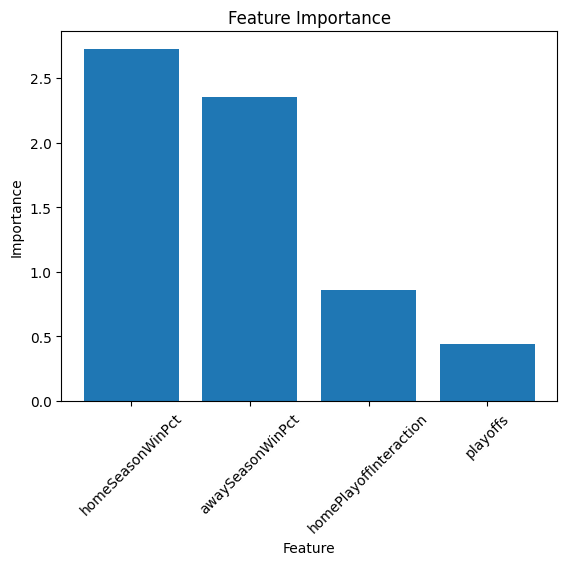

In [26]:
import matplotlib.pyplot as plt

# Bar plot  of feature importance
coef_df_log = pd.DataFrame({
    'feature': ['homeSeasonWinPct', 'awaySeasonWinPct', 'playoffs', 'homePlayoffInteraction'], 
    'coef': logmodel.coef_[0]
})

coef_df_log['abs_coef'] = coef_df_log['coef'].abs()

coef_df_log = coef_df_log.sort_values('abs_coef', ascending=False)

plt.bar(coef_df_log['feature'], coef_df_log['abs_coef'])
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**Figure 1. Feature Importance.**
This figure represents the feature importance for the logistic regression model and identifies which of the predictors have the strongest influence on win probability.

**Linear Regression Model**

In [13]:
### MODEL A (No interaction)
# create predictor variable
games['scoringDifferential'] = games['homeScore'] - games['awayScore']

# predictor and target variables
X = games[['homeSeasonWinPct', 'awaySeasonWinPct', 'playoffs']]
y = games['scoringDifferential']

# spliting dataset (70% training, 15% validation, 15% testing)
# 70% training and 30% temporary split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, random_state = 42
)

# 15% validation and 15% testing split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = 42
)

# initialize linear regression model
start = time.time()

linmodel_nointeraction = LinearRegression()

# train model on training dataset
linmodel_nointeraction.fit(X_train, y_train)

end = time.time()

# tune the model
y_val_pred = linmodel_nointeraction.predict(X_val)
y_test_pred = linmodel_nointeraction.predict(X_test)

# evaluate model
mse_val = mean_squared_error(y_val, y_val_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

rmse_val = np.sqrt(mse_val)
rmse_test = np.sqrt(mse_test)

r2_val = r2_score(y_val, y_val_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_val = mean_absolute_error(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Validation RMSE: ", rmse_val)
print("Test RMSE: ", rmse_test)
print("Validation R²: ", r2_val)
print("Test R²: ", r2_test)
print("Validation MAE: ", mae_val)
print("Test MAE: ", mae_test)
print("Training time (seconds): ", end - start)

Validation RMSE:  13.713561542916883
Test RMSE:  13.528922329150355
Validation R²:  0.13923578867803743
Test R²:  0.09752091845998401
Validation MAE:  10.750897429568441
Test MAE:  10.67003502434514
Training time (seconds):  0.03291583061218262


In [14]:
### MODEL B (Interaction)
# create predictor and target variables
games['homePlayoffInteraction'] = games['homeSeasonWinPct'] * games['playoffs']
games['scoringDifferential'] = games['homeScore'] - games['awayScore']

# predictor and target variables
X = games[['homeSeasonWinPct', 'awaySeasonWinPct', 'playoffs', 'homePlayoffInteraction']]
y = games['scoringDifferential']

In [15]:
# spliting dataset (70% training, 15% validation, 15% testing)
# 70% training and 30% temporary split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.30, random_state = 42
)

# 15% validation and 15% testing split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = 42
)

In [16]:
# initialize linear regression model
start = time.time()

linmodel = LinearRegression()

# train model on training dataset
linmodel.fit(X_train, y_train)

end = time.time()

In [17]:
# tune the model
y_val_pred = linmodel.predict(X_val)
y_test_pred = linmodel.predict(X_test)

# evaluate model
mse_val = mean_squared_error(y_val, y_val_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

rmse_val = np.sqrt(mse_val)
rmse_test = np.sqrt(mse_test)

r2_val = r2_score(y_val, y_val_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_val = mean_absolute_error(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Validation RMSE: ", rmse_val)
print("Test RMSE: ", rmse_test)
print("Validation R²: ", r2_val)
print("Test R²: ", r2_test)
print("Validation MAE: ", mae_val)
print("Test MAE: ", mae_test)
print("Training time (seconds): ", end - start)

Validation RMSE:  13.706674840343727
Test RMSE:  13.516955192079875
Validation R²:  0.1401000920417792
Test R²:  0.09911680524945277
Validation MAE:  10.752723637769313
Test MAE:  10.653951314428106
Training time (seconds):  0.022289037704467773


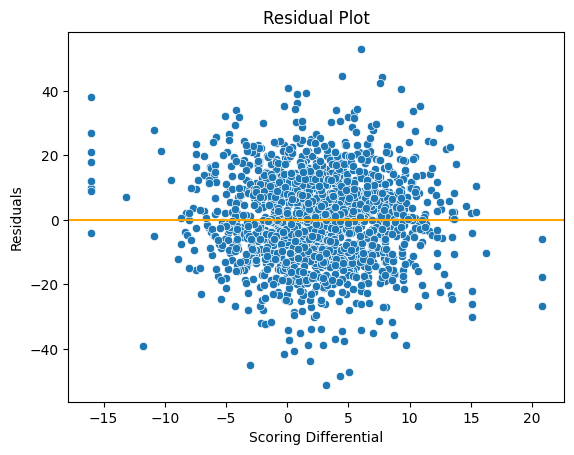

In [18]:
# Residual Plot
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = linmodel.predict(X_test)
residuals = y_test - y_pred

plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color ='orange')
plt.xlabel("Scoring Differential")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Figure 2. Residual Plot.**
This figure represents how far each game's predicted scoring differential deviated from its actual outcome.

In [27]:
# Top features
if len(linmodel.coef_.shape) > 1:
    if linmodel.coef_.shape[0] == 1:
        coefficients = linmodel.coef_[0]
    else:
        coefficients = linmodel.coef_[0]
else:
    coefficients = linmodel.coef_
    
coef_df_lin = pd.DataFrame({
    'feature': X.columns, 
    'coef': coefficients,
    'abs_coef': abs(coefficients)
}).sort_values('abs_coef', ascending=False)

print(coef_df_lin)

                  feature       coef   abs_coef
3  homePlayoffInteraction  26.065514  26.065514
0        homeSeasonWinPct  19.621860  19.621860
1        awaySeasonWinPct -17.211938  17.211938
2                playoffs -14.518578  14.518578


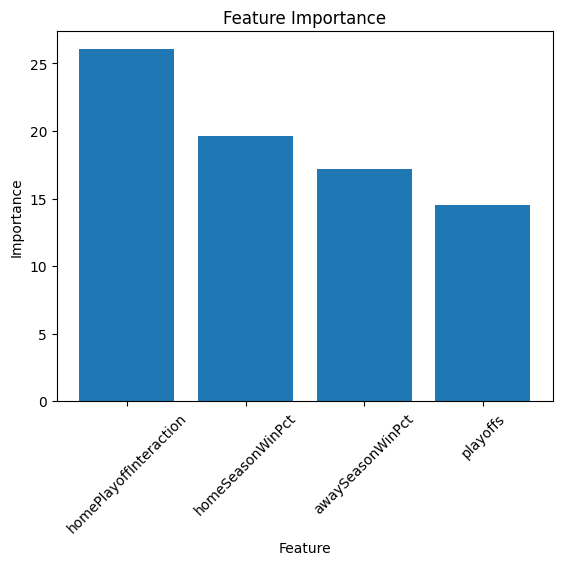

In [28]:
# Bar plot  of feature importance
coef_df_lin = pd.DataFrame({
    'feature': ['homeSeasonWinPct', 'awaySeasonWinPct', 'playoffs', 'homePlayoffInteraction'], 
    'coef': linmodel.coef_
})

coef_df_lin['abs_coef'] = coef_df_lin['coef'].abs()

coef_df_lin = coef_df_lin.sort_values('abs_coef', ascending=False)

plt.bar(coef_df_lin['feature'], coef_df_lin['abs_coef'])
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**Figure 3. Feature Importance.**
This figure represents the feature importance for the linear regression model and identifies which of the predictors have the strongest influence on scoring differential.

**Visualizations**

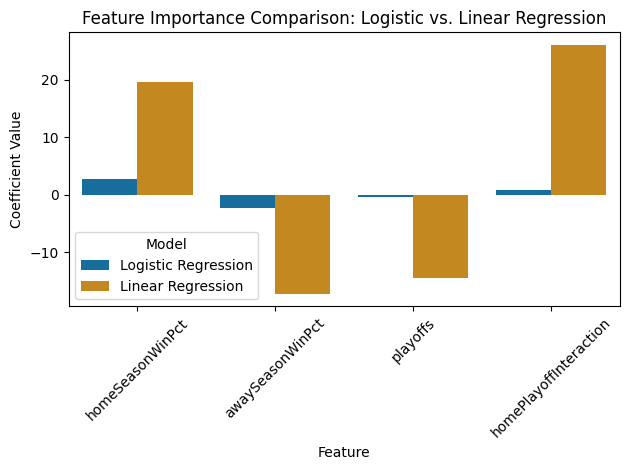

In [48]:
coef_df_log = pd.DataFrame({
    "feature": X.columns,
    "importance": logmodel.coef_[0],
    "Model": "Logistic Regression"
})

coef_df_lin = pd.DataFrame({
    "feature": X.columns,
    "importance": linmodel.coef_,
    "Model": "Linear Regression"
})

combined_importance = pd.concat([coef_df_log, coef_df_lin], axis = 0)

sns.barplot(
    data=combined_importance,
    x="feature",
    y="importance",
    hue="Model",
    palette="colorblind"
)

plt.title("Feature Importance Comparison: Logistic vs. Linear Regression")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 4. Feature Importance Comparison.**
This figure represents the comparison of the logistic and linear regression model peformance metrics. This is important to reveal how well home court advantage influences win probability and scoring differentials.

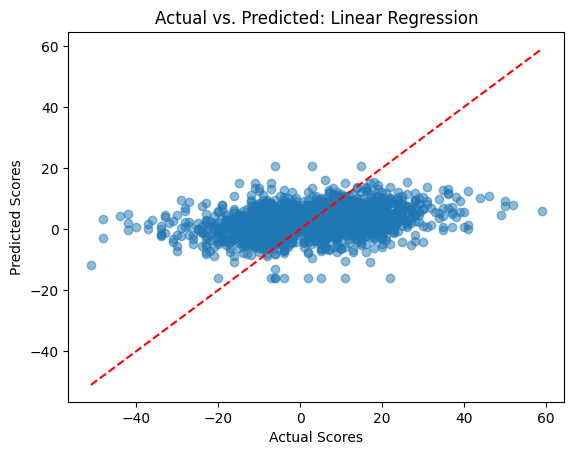

In [59]:
y_pred_lin = linmodel.predict(X_test)

plt.scatter(y_test, y_pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs. Predicted: Linear Regression")
plt.show()

**Figure 5. Actual vs. Predicted Scatter.**
This figure represents the actual vs. predicted scatter for the linear regression model. It indicates that scoring differential is difficult to predict using the features selected.

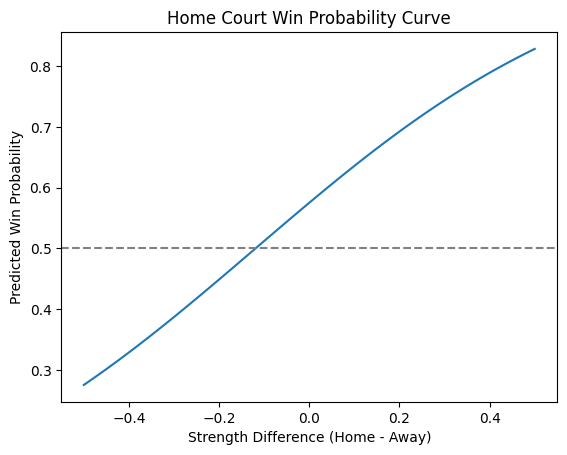

In [65]:
strength_diff = np.linspace(-0.5, 0.5, 100)

X_curve = pd.DataFrame({
    'homeSeasonWinPct': 0.5 + strength_diff/2,
    'awaySeasonWinPct': 0.5 - strength_diff/2,
    'playoffs': 0,
    'homePlayoffInteraction': 0
})

y_curve = logmodel.predict_proba(X_curve)[:, 1]

plt.plot(strength_diff, y_curve)
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel("Strength Difference (Home - Away)")
plt.ylabel("Predicted Win Probability")
plt.title("Home Court Win Probability Curve")
plt.show()

**Figure 6. Home Court Win Probability.**
This figure represents the probability that the home team wins based on the strength difference of the home vs. the away team.